# Tutorial #4: Adding Spatial Enrichment

# Adding spatial enrichment to an scFO object

In this tutorial, we will show how to add pre-computed modalities to an existing scFO object. We will add spatial enrichment scores calculated using a 43-slide cohort of GBM 10X Visium slides that were deconvolved using cell2location.

# Import packages

In [1]:
import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import muon as mu
import re
import gseapy as gp
import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import scfo

# Load scFO object and spatial scores

First, we load the pre-constructed scFO object from Tutorial #1:

In [2]:
ontology = mu.read_h5mu('scfo_mofa_gbm.h5mu')
ontology

MuData object with n_obs × n_vars = 275 × 7770
  obs:	'FactorName', 'Classification', 'Number', 'FactorType'
  uns:	'factor_type', 'gene_names', 'modality_names'
  10 modalities
    weights:	275 x 6989
    hallmark:	275 x 50
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_sets', 'modality_type'
      layers:	'pval'
    literature:	275 x 29
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_sets', 'modality_type'
      layers:	'pval'
    regulons:	275 x 368
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_ligand:	275 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_receptor:	275 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
      layers:	'pval'
    slice_treatment:	275 x 9
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
      layers:	'pval'
    survival_scores:	275 x 10
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
    spatial_global_corr:	275 x 286
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'modality_type', 'scored_cell_type_aware'
    spatial_niche:	275 x 7
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'

Next, we load the spatial data. We have computed two sets of spatially-informed statistics based on projecting the MOFA factors onto 10X Visium spots:
- Global bi-variate Moran's I correlation between every pair-wise factor combination, as well as inferred cell type abundance scores
- Enrichment (factor mean across spots) of each factor in spatial niches, defined as meta-clusters of the spatial/expression joint graph across samples.

In [3]:
all_biv_corr = pd.read_csv('Priors/all_biV_corr.csv', index_col = 0)
all_biv_corr

,Astrocyte|abundance,Endothelial|abundance,Mg_TAM|abundance,Mo_TAM|abundance,Neuron|abundance,Non_Mac_Myelocyte|abundance,Non_T_Lymphocyte|abundance,Oligo|abundance,Pericyte|abundance,T cell|abundance,...,Factor16|Tumor,Factor17|Tumor,Factor18|Tumor,Factor19|Tumor,Factor20|Tumor,Factor21|Tumor,Factor22|Tumor,Factor23|Tumor,Factor24|Tumor,patient
Astrocyte|abundance,0.881123,0.912993,0.845896,0.872545,0.876369,0.615122,0.696910,0.920550,0.907185,0.783123,...,0.691419,-0.554107,-0.639024,0.761726,-0.182814,0.049983,-0.280026,-0.147919,0.781704,GSM8506649_03422
Endothelial|abundance,0.909005,0.871772,0.872116,0.875457,0.876672,0.653281,0.682008,0.910819,0.925438,0.808460,...,0.733658,-0.586475,-0.649806,0.775063,-0.223117,0.006782,-0.248911,-0.209411,0.794069,GSM8506649_03422
Mg_TAM|abundance,0.842819,0.872208,0.865839,0.853485,0.811801,0.665581,0.649621,0.850029,0.854314,0.781852,...,0.678131,-0.594745,-0.557049,0.737380,-0.238255,0.116566,-0.293600,-0.209615,0.797596,GSM8506649_03422
Mo_TAM|abundance,0.863465,0.869727,0.847667,0.862806,0.785213,0.722090,0.697388,0.839430,0.874117,0.774743,...,0.741450,-0.453825,-0.701711,0.786723,-0.248974,-0.133732,-0.065329,-0.063987,0.739905,GSM8506649_03422
Neuron|abundance,0.828062,0.832057,0.771462,0.751458,0.796352,0.619221,0.685747,0.867202,0.799004,0.787465,...,0.618133,-0.473986,-0.545781,0.663459,-0.129530,-0.008759,-0.264126,-0.122517,0.653384,GSM8506649_03422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Factor20|Tumor,-0.341414,-0.194159,-0.191384,-0.121558,-0.328592,-0.210051,-0.111547,0.003582,-0.176949,-0.122449,...,-0.174199,-0.307886,0.278882,-0.197848,0.380455,-0.087066,-0.165185,-0.374660,-0.031563,#UKF334_T_ST
Factor21|Tumor,-0.035430,-0.169438,-0.140676,-0.380353,0.390371,-0.314901,-0.296449,0.136304,-0.233236,-0.263840,...,0.365626,-0.068742,0.025685,0.328153,-0.097888,0.572757,-0.446840,-0.005795,0.327430,#UKF334_T_ST
Factor22|Tumor,0.450836,0.410988,0.357802,0.497700,-0.128268,0.511851,0.426799,0.042262,0.447622,0.373311,...,-0.142194,-0.025295,-0.323290,0.066077,-0.182038,-0.425143,0.495551,0.465455,0.042469,#UKF334_T_ST
Factor23|Tumor,0.696999,0.514445,0.431906,0.397930,0.165599,0.543934,0.488384,0.258150,0.465631,0.427386,...,0.067625,0.077796,-0.557392,0.389785,-0.453103,0.001678,0.507569,0.635439,0.278633,#UKF334_T_ST


In [4]:
niche_enr = pd.read_csv('Priors/all_factor_metacluster_profiles.csv', index_col = 0)
niche_enr

,Factor0|Astrocyte,Factor1|Astrocyte,Factor2|Astrocyte,Factor3|Astrocyte,Factor4|Astrocyte,Factor5|Astrocyte,Factor6|Astrocyte,Factor7|Astrocyte,Factor8|Astrocyte,Factor9|Astrocyte,...,Factor15|Tumor,Factor16|Tumor,Factor17|Tumor,Factor18|Tumor,Factor19|Tumor,Factor20|Tumor,Factor21|Tumor,Factor22|Tumor,Factor23|Tumor,Factor24|Tumor
metacluster_annotated,,,,,,,,,,,,,,,,,,,,,
Immunoregulatory TAM niche,14.551629,-6.521342,34.888539,-4.407580,-7.092308,-11.207494,11.453504,32.800602,-7.203383,1.760877,...,14.055304,4.066180,-1.001193,-7.195138,6.650434,-3.030227,-2.019271,5.324918,7.359309,4.854059
Inflammatory / interferon-active niche,13.148754,-6.223640,30.235448,-3.866579,-5.070968,-10.677008,10.587964,27.776955,-6.099989,1.954898,...,14.123033,4.500563,-0.030809,-7.044835,6.304956,-3.950182,-1.451745,4.623727,7.136726,4.347883
Mesenchymal-hypoxic TAM-rich core,16.032727,-9.514165,34.652070,-4.338094,-4.753130,-10.217399,14.226166,31.679781,-7.816407,0.937998,...,11.096153,2.974933,0.992571,-6.295356,5.027299,-3.048482,-3.817377,6.377690,7.655528,3.496925
Mixed / low-signal baseline niche,12.618607,-5.893026,34.407216,-4.659553,-5.199637,-12.526688,8.310903,32.600496,-6.122096,2.284667,...,16.659028,5.020595,1.677351,-8.040764,6.823064,-5.770651,0.261329,4.154464,8.801644,4.925404
Neural-like differentiated tumor,16.252946,-6.271928,38.802187,-3.112271,-8.288138,-12.998147,11.081721,36.103963,-8.388767,1.453442,...,12.113642,2.373929,0.248230,-5.848379,5.666273,-2.931872,-2.855006,6.096949,7.733012,4.351913
Reactive stromal / ECM tumor niche,13.044072,-7.356504,31.009018,-4.399913,-5.605965,-10.194169,9.552728,28.736908,-5.588865,1.916884,...,13.132503,4.550793,-0.647130,-7.370303,5.885153,-3.765486,-1.220262,4.152893,6.764159,4.078451
Tumor-immune interface,11.706463,-6.713160,27.941240,-2.914768,-3.372847,-8.814502,5.777872,24.103518,-7.566317,0.994661,...,9.305847,2.607604,-0.081254,-5.474945,4.393615,-2.766696,-2.957756,4.983267,5.905124,3.272234


Since the spatial correlations were calculated for each slide/patient, we need to summarize by taking the mean:

In [5]:
all_biv_corr.drop(columns = 'patient', inplace = True)
all_biv_corr['var_name'] = all_biv_corr.index
mean_biv_corr = all_biv_corr.groupby('var_name').mean().loc[ontology.obs.index]
mean_biv_corr.columns = mean_biv_corr.columns.astype(str).str.replace('|', '::', regex = False)

Let's see if there are global patterns of spatial correlation/organization across factors:

/Users/matthewwarren/anaconda3/envs/mmochi/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


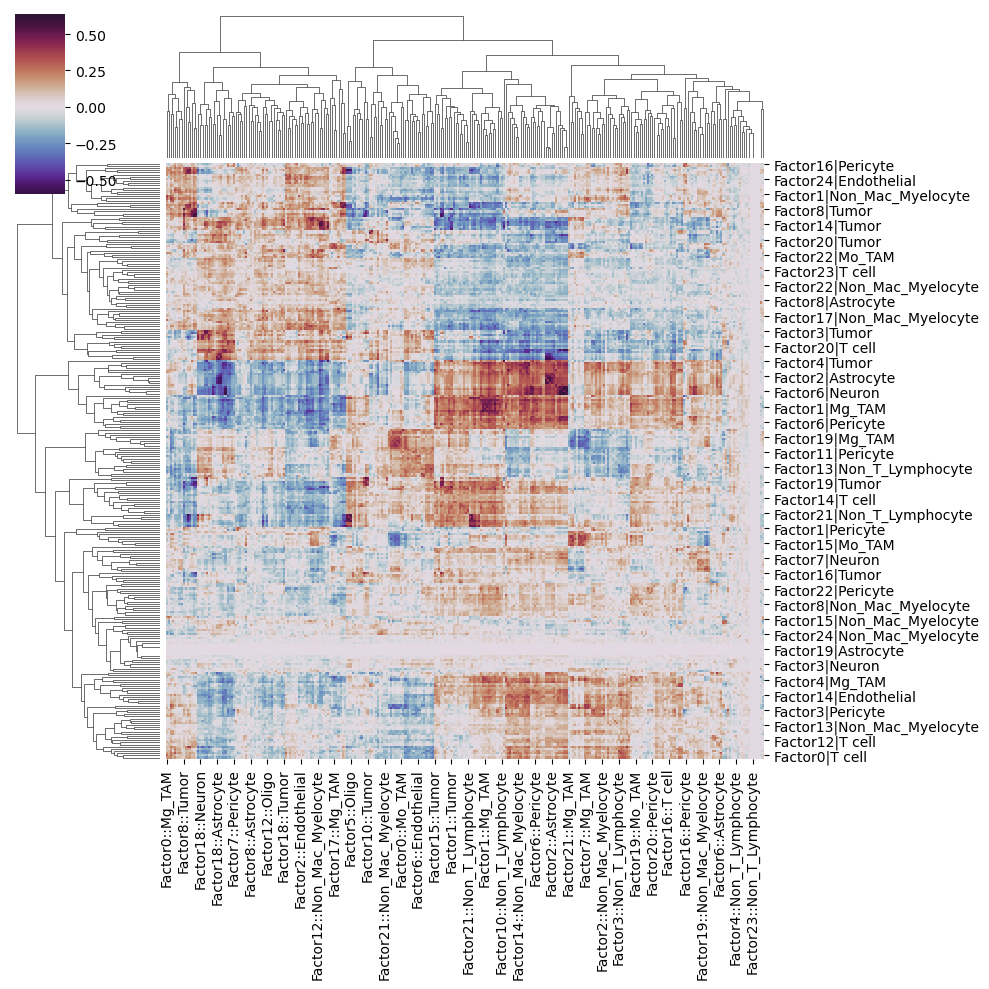

In [6]:
sns.clustermap(mean_biv_corr, center = 0, cmap = 'twilight_shifted')

And then we can visualize spatial nice enrichment:

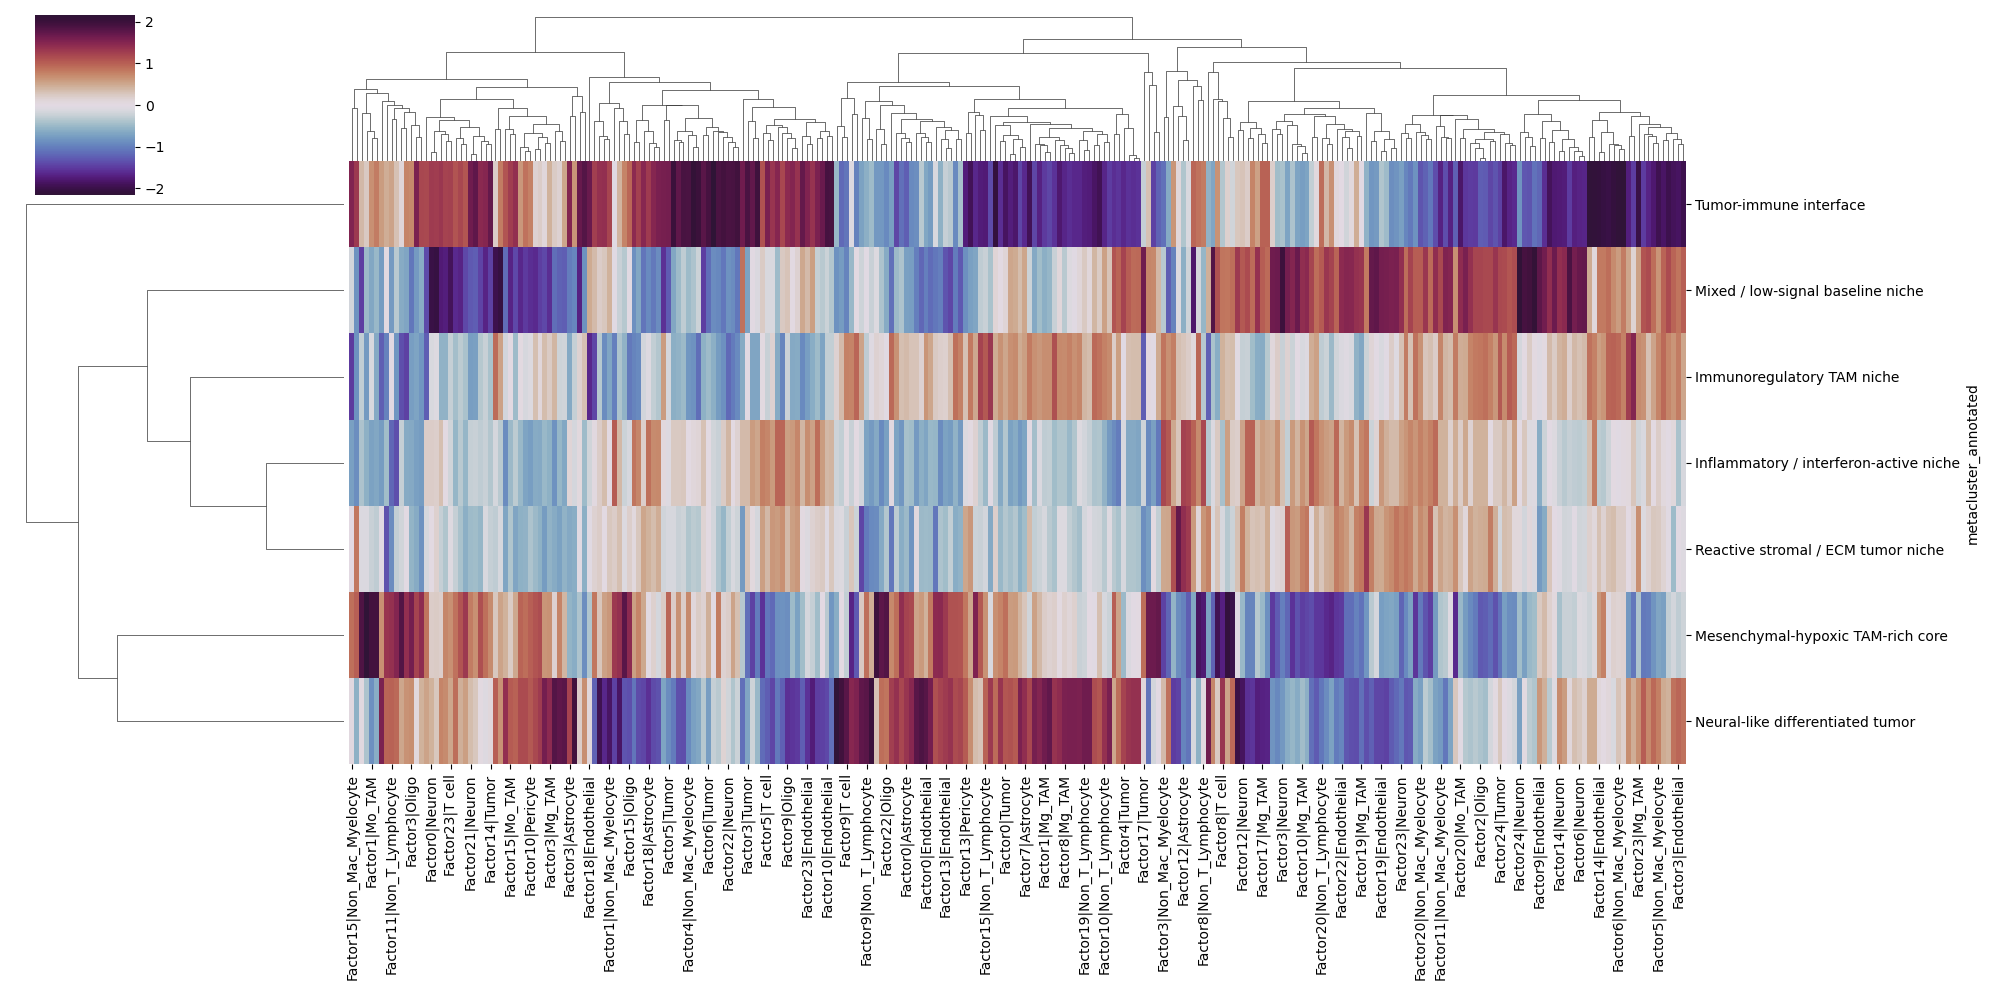

In [7]:
niche_enr = niche_enr[niche_enr.var()[niche_enr.var() > 0].index]
sns.clustermap(niche_enr.fillna(0), center = 0, cmap = 'twilight_shifted', figsize = (20, 10), z_score = 1)

It looks like both the global correlation and niche enrichment metrics provide interesting information for the factors. Let's add them to our ontology object!

This is easy using the `add_modality()` function. Since these statistics were computed separately, no enrichment (permutation or GSEA) is necessary. However, this function also works if only loadings are provided and calculates enrichment.

In [8]:
scfo.add_modality(
    ontology, 
    modality_name = 'spatial_global_corr',
    score_df = mean_biv_corr,
    modality_type = 'precomputed',
)

For the spatial niche modality, we will also add metacluster gene markers to the `.varm["feature_loadings"]` slot, in case we want to visualize niche markers later:

In [9]:
niche_loadings = pd.read_csv('Priors/all_spatial_metacluster_markers.csv', index_col = 0)
niche_loadings

,Inflammatory / interferon-active niche,Immunoregulatory TAM niche,Neural-like differentiated tumor,Reactive stromal / ECM tumor niche,Mesenchymal-hypoxic TAM-rich core,Mixed / low-signal baseline niche,Tumor-immune interface
gene,,,,,,,
A2M,-2.060548,5.097823,6.437317,0.514976,-2.350115,-3.726796,-8.474517
AAAS,-1.758280,0.941667,3.332767,-0.689866,0.531910,0.037655,-5.052659
AACS,-1.880046,-0.192051,1.589623,-0.996728,0.487796,3.347946,-3.486229
AAGAB,-1.959635,0.614414,2.806691,-0.930615,-0.019932,1.866272,-4.378964
AAK1,-2.572552,0.078278,1.794487,-1.326670,0.221688,4.808075,-4.570413
...,...,...,...,...,...,...,...
ZXDB,-0.649436,0.190927,0.919787,-0.395554,0.070724,0.530393,-1.426035
ZXDC,-0.922134,0.699183,1.947420,-0.398727,0.040996,-0.293792,-2.923106
ZYG11B,-3.007760,0.319795,2.705885,-1.568255,0.075115,4.820999,-5.916108


In [10]:
scfo.add_modality(
    ontology, 
    modality_name = 'spatial_niche',
    score_df = niche_enr.T,
    modality_type = 'precomputed',
    feature_loadings = niche_loadings
)

Let's take a look at our updated `ontology` object:

In [11]:
ontology

MuData object with n_obs × n_vars = 275 × 7770
  obs:	'FactorName', 'Classification', 'Number', 'FactorType'
  uns:	'factor_type', 'gene_names', 'modality_names'
  10 modalities
    weights:	275 x 6989
    hallmark:	275 x 50
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_sets', 'modality_type'
      layers:	'pval'
    literature:	275 x 29
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'gene_sets', 'modality_type'
      layers:	'pval'
    regulons:	275 x 368
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_ligand:	275 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
      layers:	'pval'
    liana_receptor:	275 x 11
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
      layers:	'pval'
    slice_treatment:	275 x 9
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
      layers:	'pval'
    survival_scores:	275 x 10
      obs:	'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'cell_type_separator', 'collapse_cell_type_aware_scores', 'feature_loading_key_default', 'feature_loading_row_axis', 'gene_names', 'modality_type', 'scored_cell_type_aware'
      varm:	'feature_loadings'
    spatial_global_corr:	275 x 286
      obs:	'hallmark:FactorName', 'hallmark:Classification', 'hallmark:Number', 'hallmark:FactorType', 'literature:FactorName', 'literature:Classification', 'literature:Number', 'literature:FactorType', 'regulons:FactorName', 'regulons:Classification', 'regulons:Number', 'regulons:FactorType', 'liana_ligand:FactorName', 'liana_ligand:Classification', 'liana_ligand:Number', 'liana_ligand:FactorType', 'liana_receptor:FactorName', 'liana_receptor:Classification', 'liana_receptor:Number', 'liana_receptor:FactorType', 'slice_treatment:FactorName', 'slice_treatment:Classification', 'slice_treatment:Number', 'slice_treatment:FactorType', 'survival_scores:FactorName', 'survival_scores:Classification', 'survival_scores:Number', 'survival_scores:FactorType', 'spatial_global_corr:FactorName', 'spatial_global_corr:Classification', 'spatial_global_corr:Number', 'spatial_global_corr:FactorType', 'spatial_niche:FactorName', 'spatial_niche:Classification', 'spatial_niche:Number', 'spatial_niche:FactorType', 'FactorName', 'Classification', 'Number', 'FactorType'
      uns:	'modality_type', 'feature_loading_key_default', 'scored_cell_type_aware', 'cell_type_separator', 'collapse_cell_type_aware_scores'
    spatial_niche:	275 x 7
      obs:	'hallmark:FactorName', 'hallmark:Classification', 'hallmark:Number', 'hallmark:FactorType', 'literature:FactorName', 'literature:Classification', 'literature:Number', 'literature:FactorType', 'regulons:FactorName', 'regulons:Classification', 'regulons:Number', 'regulons:FactorType', 'liana_ligand:FactorName', 'liana_ligand:Classification', 'liana_ligand:Number', 'liana_ligand:FactorType', 'liana_receptor:FactorName', 'liana_receptor:Classification', 'liana_receptor:Number', 'liana_receptor:FactorType', 'slice_treatment:FactorName', 'slice_treatment:Classification', 'slice_treatment:Nu

Let's also visualize spatial scores for an individual factor:

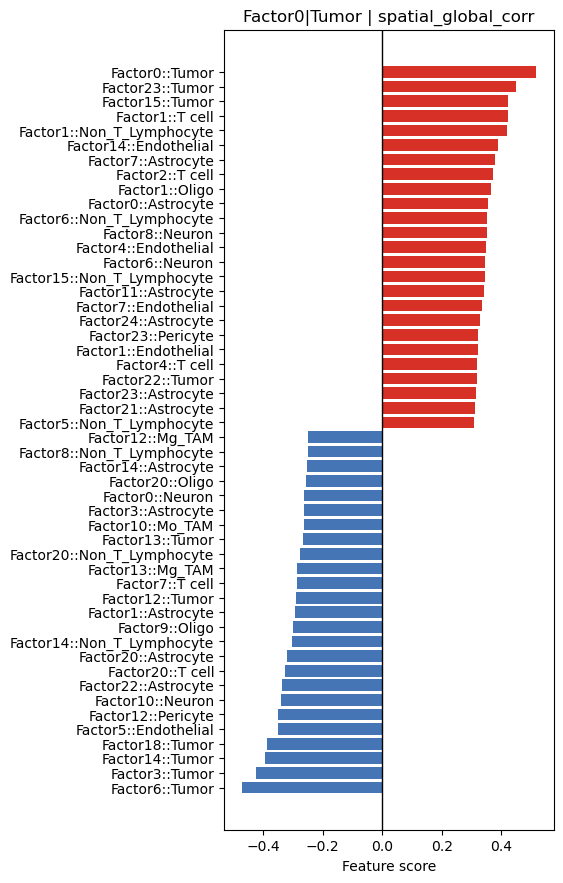

In [12]:
factor = 'Factor0|Tumor'
mod = 'spatial_global_corr'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=25,
    n_neg = 25,
    figsize = (3.3, 8),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

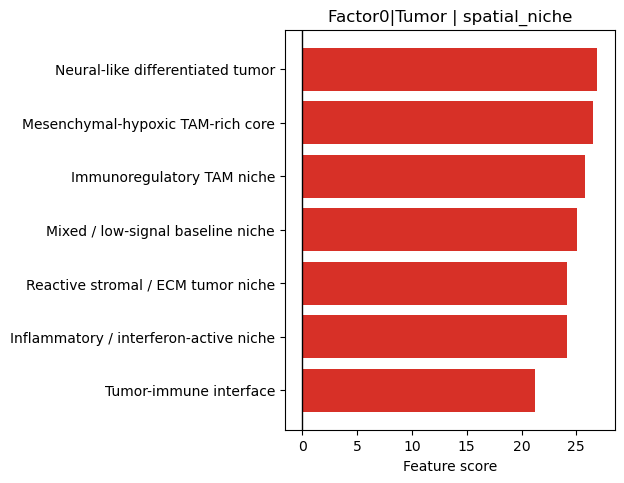

In [13]:
factor = 'Factor0|Tumor'
mod = 'spatial_niche'

fig, ax = scfo.plot_factor_top_features(
    ontology,
    factor=factor,
    modality=mod,
    n_pos=7,
    n_neg = 0,
    figsize = (3.3, 4),
    #path = 'Figures/'+factor+'_'+mod+'.svg'
)

We can also visualize the spatial niche top markers:

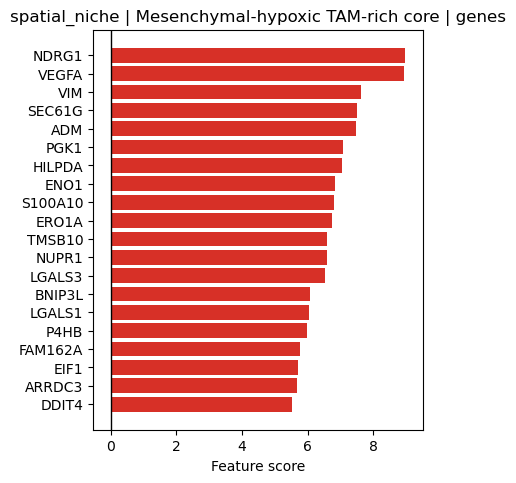

In [14]:
fig, ax = scfo.plot_modality_feature_top_items(
    ontology,
    modality="spatial_niche",
    feature="Mesenchymal-hypoxic TAM-rich core",
    what="genes",
    n_pos=20,
    n_neg=0,
    figsize = (3.3, 4)
)

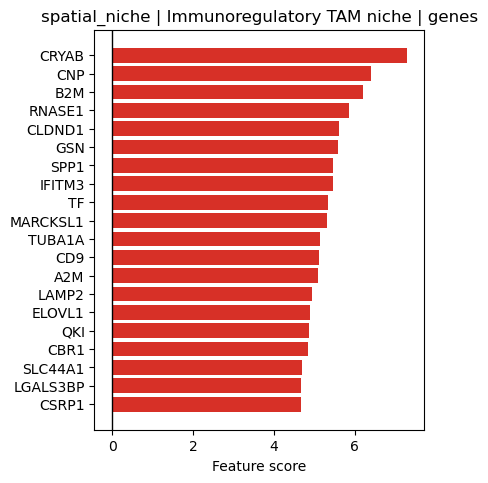

In [15]:
fig, ax = scfo.plot_modality_feature_top_items(
    ontology,
    modality="spatial_niche",
    feature="Immunoregulatory TAM niche",
    what="genes",
    n_pos=20,
    n_neg=0,
    figsize = (3.3, 4)
)

Great, we now have added spatial annotations to our scFO object! Let's save it for future use:

In [16]:
ontology.write_h5mu('scfo_mofa_gbm_w_spatial.h5mu')